In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Advertising.csv', usecols=["TV","Radio","Newspaper","Sales"])
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [4]:
#Let's convert to numpy
colPredictors = data.columns[:-1]
colResponse = data.columns[-1]
X = data[colPredictors].to_numpy()

y = data[colResponse].to_numpy()

# Least Square Error solution
As we previously discussed, the LSE provide the analytical solution for our problem.

If we want to find our coefficients for $Xb=y$, we used the equation:

$ b = (X^{T}X^{-1})X^{T}y$

We extend first X, to include a column for the intercept

In [5]:
 X

array([[230.1,  37.8,  69.2],
       [ 44.5,  39.3,  45.1],
       [ 17.2,  45.9,  69.3],
       [151.5,  41.3,  58.5],
       [180.8,  10.8,  58.4],
       [  8.7,  48.9,  75. ],
       [ 57.5,  32.8,  23.5],
       [120.2,  19.6,  11.6],
       [  8.6,   2.1,   1. ],
       [199.8,   2.6,  21.2],
       [ 66.1,   5.8,  24.2],
       [214.7,  24. ,   4. ],
       [ 23.8,  35.1,  65.9],
       [ 97.5,   7.6,   7.2],
       [204.1,  32.9,  46. ],
       [195.4,  47.7,  52.9],
       [ 67.8,  36.6, 114. ],
       [281.4,  39.6,  55.8],
       [ 69.2,  20.5,  18.3],
       [147.3,  23.9,  19.1],
       [218.4,  27.7,  53.4],
       [237.4,   5.1,  23.5],
       [ 13.2,  15.9,  49.6],
       [228.3,  16.9,  26.2],
       [ 62.3,  12.6,  18.3],
       [262.9,   3.5,  19.5],
       [142.9,  29.3,  12.6],
       [240.1,  16.7,  22.9],
       [248.8,  27.1,  22.9],
       [ 70.6,  16. ,  40.8],
       [292.9,  28.3,  43.2],
       [112.9,  17.4,  38.6],
       [ 97.2,   1.5,  30. ],
       [26

In [6]:
X_extended = np.hstack( [ np.ones( [X.shape[0] ,1]), X] )
X_extended

array([[  1. , 230.1,  37.8,  69.2],
       [  1. ,  44.5,  39.3,  45.1],
       [  1. ,  17.2,  45.9,  69.3],
       [  1. , 151.5,  41.3,  58.5],
       [  1. , 180.8,  10.8,  58.4],
       [  1. ,   8.7,  48.9,  75. ],
       [  1. ,  57.5,  32.8,  23.5],
       [  1. , 120.2,  19.6,  11.6],
       [  1. ,   8.6,   2.1,   1. ],
       [  1. , 199.8,   2.6,  21.2],
       [  1. ,  66.1,   5.8,  24.2],
       [  1. , 214.7,  24. ,   4. ],
       [  1. ,  23.8,  35.1,  65.9],
       [  1. ,  97.5,   7.6,   7.2],
       [  1. , 204.1,  32.9,  46. ],
       [  1. , 195.4,  47.7,  52.9],
       [  1. ,  67.8,  36.6, 114. ],
       [  1. , 281.4,  39.6,  55.8],
       [  1. ,  69.2,  20.5,  18.3],
       [  1. , 147.3,  23.9,  19.1],
       [  1. , 218.4,  27.7,  53.4],
       [  1. , 237.4,   5.1,  23.5],
       [  1. ,  13.2,  15.9,  49.6],
       [  1. , 228.3,  16.9,  26.2],
       [  1. ,  62.3,  12.6,  18.3],
       [  1. , 262.9,   3.5,  19.5],
       [  1. , 142.9,  29.3,  12.6],
 

Split in trainign and test. We find coefficients using only train, and then we evaluate the model on the test set.

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets, with 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_extended, y, test_size=0.2, random_state=42)

In [9]:
import time

# Start the timer
start_time = time.time()

beta = np.linalg.inv(X_train.T @ X_train ) @ X_train.T @y_train

# End the timer
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time

print('coefficients: ' ,beta  )

coefficients:  [2.97906734e+00 4.47295175e-02 1.89195054e-01 2.76111434e-03]


We can plot the predicted values vs the actual one. As this is regression, we expect to see a 45 degree line if the predictions are accurate

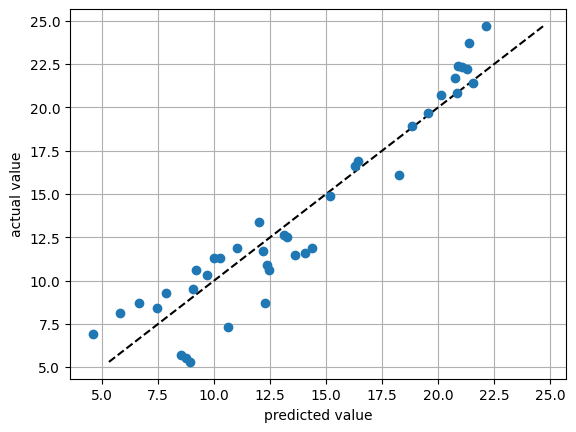

In [10]:
yHat =  X_test @ beta

plt.figure( )
plt.plot( [np.min(y_test), np.max(y_test) ], [ np.min(y_test), np.max(y_test) ] , '--k') # reference line
plt.plot(yHat, y_test, 'o' )
plt.xlabel( 'predicted value')
plt.ylabel( 'actual value')
plt.grid()

# Gradient descendent

For GD, it is better to MSE rather than SSE. The reason is to provide stability during the updating approach. MSE is defined as:

$J(b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y_i} )^2$

$J(b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - X_ib)^2$

$J(b) = \frac{1}{N} \sum_{i=1}^{N} (y_i -  \sum_{j=0}^{3}  X_{i,j} b_j)^2$

$J(b) = \frac{1}{N} \sum_{i=1}^{N} [y_i -  (X_{i,0} b_0 + X_{i,1} b_1 + X_{i,2} b_2+ X_{i,3} b_3) ]^2$

We want to minimize our cost function, so we can use gradient descendent. First, we need to calculate the gradiant of the cost function with regard b. b is a vector that contains the entries of each coefficient, namely $b=[b_0, b_1, b_2, b_3]^T$

We need to derivate our cost function, J(b) with respect to each coefficient.

$\frac{\partial J(b)}{\partial b_0} = \frac{\partial \sum_{i=1}^{N} [y_i -  (X_{i,0} b_0 + X_{i,1} b_1 + X_{i,2} b_2 + X_{i,3} b_3) ]^2 }{\partial b_0}$  


$\frac{\partial J(b)}{\partial b_0} = -2 \sum_{i=1}^{N} (y_i - X_ib)x_0 $

Similarly, we can do for $b_1$, $b_2$ and $b_3$

$\frac{\partial J(b)}{\partial b_1} = \frac{-2}{N}  \sum_{i=1}^{N} (y_i - X_ib)x_1 $

$\frac{\partial J(b)}{\partial b_2} = \frac{-2}{N} \sum_{i=1}^{N} (y_i - X_ib)x_2 $

$\frac{\partial J(b)}{\partial b_3} = \frac{-2}{N} \sum_{i=1}^{N} (y_i - X_ib)x_3 $

We can vectorize (write the equation using as matrix multiplication) as:

$\frac{\partial J(b)}{\partial b} = \frac{-2}{N} X^{T} (Y-Xb) $

Vectorized version is prefered as it help to compute faster the gradient descendent algorithm. Summation requires loops, which needs more computation cycles.


In [11]:
#Let's wirte a function that returns the gradient given the X and b

def grad( X, y, b):
    Nx = X.shape[0]
    #making y a column vector
    y = y.reshape(-1,1)

    #applying the gradient
    g = -2/Nx * X.T @ ( y - X@b )
    
    return g



Now, we can use the gradiant to use an iterative algorithm to update the vector b as:

$ b^{k+1} = b^{k} - \eta\times grad_b $ 

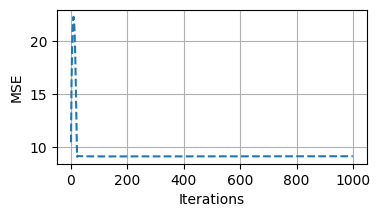

In [12]:
stop = False
counter = 0
totalSamples = X.shape[0]
#A_ds = np.random.rand(3, 3)
A_ds = np.zeros( [3, 3])
eta = 1e-4
iterations = 1000

#intial beta as zero
b = np.zeros( (X_train.shape[1], 1) )

rList = []

start_time = time.time()
while not stop:
    
    yPred = X_train @ b 
    
    mse = (1/len(y))* np.sum( ( y  - yPred  )**2)

    rList.append( mse )
    
    grad_beta = grad( X_train, y_train, b)
 
    
    learning_rate = eta/np.sqrt( counter+1) 
    


    b = b - learning_rate * grad_beta
  
    counter+=1
    if (counter == iterations) :
        stop=True

# End the timer
end_time= time.time()

# Calculate elapsed time
elapsed_time_gd  = end_time - start_time


plt.figure(figsize=(4,2) )
plt.plot(np.arange( iterations) , np.log(rList), '--' )
plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.grid()
plt.show()

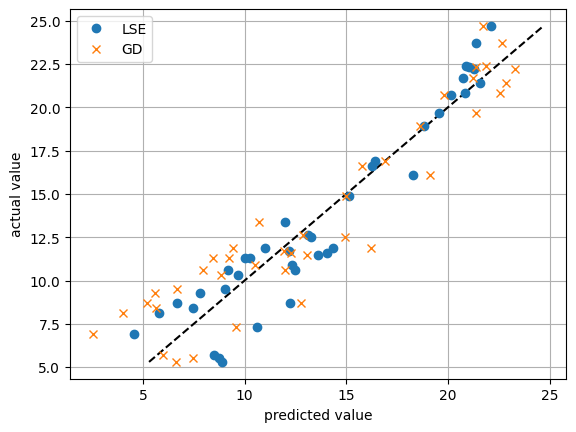

In [13]:
yHat_gd =  X_test @ b

plt.figure( )
plt.plot( [np.min(y_test), np.max(y_test) ], [ np.min(y_test), np.max(y_test) ] , '--k') # reference line
plt.plot(yHat, y_test, 'o', label='LSE' )
plt.plot(yHat_gd, y_test, 'x' , label='GD')
plt.xlabel( 'predicted value')
plt.ylabel( 'actual value')
plt.legend()
plt.grid()
plt.show()

# Stochastic gradient descendent

As we saw, we can also use only one sample to update the cost function

$J(b) =  (y_i - x_ib)^2$

The partial derivate of $J(b)$ with respect to $b_j$ is:

$\frac{\partial J(b)}{\partial b_j} = -2 (y_i - x_ib)x_i $

The vectorized form is:

$\frac{\partial J(b)}{\partial b} = -2 x^{T} (y_i-x_ib) $


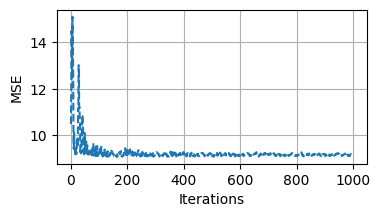

In [14]:

import random

# Set the seed
seed_value = 42  # You can use any integer value as the seed
random.seed(seed_value)


stop = False
counter = 0
totalSamples = X_train.shape[0]
b_s = np.zeros( [4, 1]) #np.random.rand(3, 3)

eta = 1e-4
rList = []
iterations = 1000
doSequential = True
start_time = time.time()
while not stop:
    
    yPred = X_train @ b_s 
    
    mse = (1/len(y))* np.sum( ( y  - yPred  )**2)

    rList.append( mse )

    if doSequential:
        # sequential
        pos = counter%totalSamples
    else:
        #randomly selecting a sample
        
        pos =  random.randint(0, totalSamples-1 )
        #print(f'iteration {counter} pos {pos}') 

        
    sample = X_train[pos].reshape(1,-1) # one row, features in columns
    
    
    grad_beta  = grad( sample, y_train[pos], b_s) # -2* sample.T @ ( y_train[pos].reshape(-1,1) - sample@b_s )
    
    learningRate = eta/ np.sqrt(counter+1)
    
    b_s = b_s - (learningRate )*grad_beta
    
    
    counter+=1
    if (counter == iterations) :
        stop=True
        
# End the timer
end_time= time.time()

# Calculate elapsed time
elapsed_time_s  = end_time - start_time




plt.figure(figsize=(4,2))
plt.plot(np.arange( iterations) , np.log(rList), '--' )
plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.grid()
plt.show()



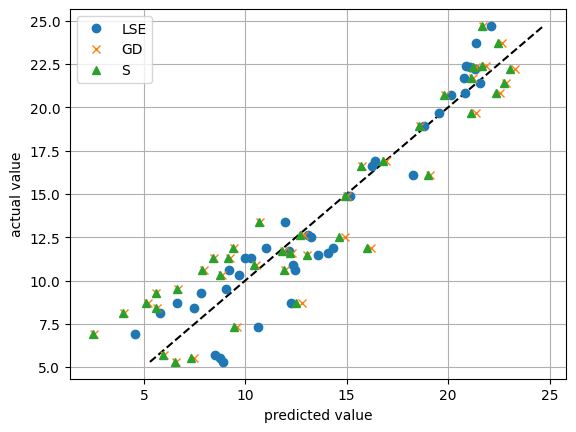

In [15]:

yHat_s =  X_test @ b_s

plt.figure( )
plt.plot( [np.min(y_test), np.max(y_test) ], [ np.min(y_test), np.max(y_test) ] , '--k') # reference line
plt.plot(yHat, y_test, 'o', label='LSE' )
plt.plot(yHat_gd, y_test, 'x' , label='GD')
plt.plot(yHat_s, y_test, '^' , label='S')
plt.xlabel( 'predicted value')
plt.ylabel( 'actual value')
plt.legend()
plt.grid()
plt.show()


In [16]:
print(f'times LSE:{elapsed_time}, gradient descendent {elapsed_time_gd},  stochastic {elapsed_time_s}') 

times LSE:0.0002849102020263672, gradient descendent 0.05203104019165039,  stochastic 0.05153203010559082


MSE for least sqaures:3.174097353976104, gradient descendent:70.13420535649615, and stochastic gd:69.80074580039772


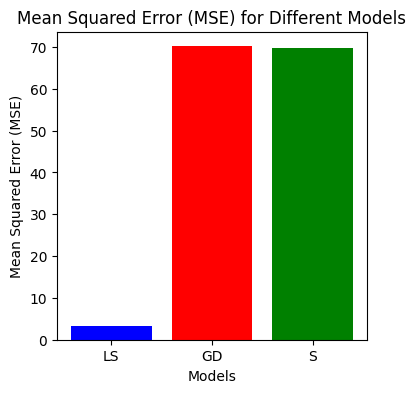

In [17]:
MSE_LS = np.mean( (y_test - yHat)**2 )
MSE_GD = np.mean( (y_test - yHat_gd)**2 )
MSE_S = np.mean( (y_test - yHat_s)**2 )

print('MSE for least sqaures:{}, gradient descendent:{}, and stochastic gd:{}'.format( MSE_LS, MSE_GD, MSE_S) )


# Data
models = ['LS', 'GD', 'S']
mse_values = [MSE_LS, MSE_GD, MSE_S]

# Create bar plot
plt.figure(figsize=(4,4))
plt.bar(models, mse_values, color=['blue', 'red', 'green'])
plt.xlabel('Models')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean Squared Error (MSE) for Different Models')
plt.show()